In [1]:
%load_ext rpy2.ipython

In [2]:
from google.colab import files
uploaded = files.upload()

Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving deliveries.csv to deliveries.csv
Saving orders.csv to orders.csv


In [3]:
%%R

install.packages("sqldf")
install.packages("DBI")
install.packages("RSQLite")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cran.rstudio.com/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_3.52.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp5NZmd6/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/DBI_1.3.0.tar.gz'
Content type 'application/x-gzip' length 744704 bytes (727 KB)
downloaded 727 KB


The downloaded source packages are in
	‘/tmp/Rtmp5NZmd6/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rst

In [4]:
%%R

library(sqldf)
library(DBI)
library(RSQLite)
library(ggplot2)

print("R libraries loaded successfully")

[1] "R libraries loaded successfully"


Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite
In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [5]:
%%R

customers <- read.csv("customers.csv")

orders <- read.csv("orders.csv")

deliveries <- read.csv("deliveries.csv")

complaints <- read.csv("complaints.csv")

print(head(customers))
print(head(orders))

  customer_id age home_zone customer_type         signup_date loyalty_score
1       C0001  26     North           SME 2024-11-27 04:25:00          44.9
2       C0002  61   AIRPORT      Consumer 2025-10-28 01:04:00          55.4
3       C0003  66      East      Consumer 2025-07-02 03:23:00          75.9
4       C0004  75   CENTRAL      Consumer 2025-08-19 01:58:00          32.5
5       C0005  26 Riverside      Consumer 2025-06-03 06:02:00          55.9
6       C0006  41      WEST      Consumer 2024-03-29 13:26:00          39.9
  app_engagement_score preferred_channel account_status
1                 69.2               App         Active
2                 66.6               App         Active
3                 33.8                           Active
4                 33.0               App         Active
5                100.0               Web         Active
6                 43.3               Web         Active
  order_id customer_id service_type    order_created_at promised_window_hour

In [6]:
%%R

high_value_orders <- sqldf("
SELECT
    service_type,
    COUNT(*) AS total_orders,
    AVG(order_value) AS average_order_value
FROM orders
GROUP BY service_type
ORDER BY average_order_value DESC
")

print(high_value_orders)

  service_type total_orders average_order_value
1    Passenger          341            96.07364
2     Business          165            92.24503
3       Retail          297            90.01367
4       Parcel          308            87.61565
5      Medical          139            87.13619


In [7]:
%%R

complaint_analysis <- sqldf("
SELECT
    complaint_type,
    COUNT(*) AS total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

print(complaint_analysis)

     complaint_type total_complaints
1             Delay              101
2      MissedPickup               64
3          AppIssue               53
4   DriverBehaviour               51
5 SupportExperience               20
6           Billing               16
7            Damage               15


In [8]:
%%R

joined_analysis <- sqldf("
SELECT
    o.service_type,
    d.delivery_status,
    COUNT(*) AS total
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY o.service_type, d.delivery_status
")

print(joined_analysis)

   service_type delivery_status total
1      Business         Delayed    28
2      Business          Failed    25
3      Business          OnTime    73
4       Medical         Delayed    22
5       Medical          Failed    16
6       Medical          OnTime    70
7        Parcel         Delayed    49
8        Parcel          Failed    25
9        Parcel          OnTime   156
10    Passenger         Delayed    53
11    Passenger          Failed    38
12    Passenger          OnTime   171
13       Retail         Delayed    50
14       Retail          Failed    28
15       Retail          OnTime   146


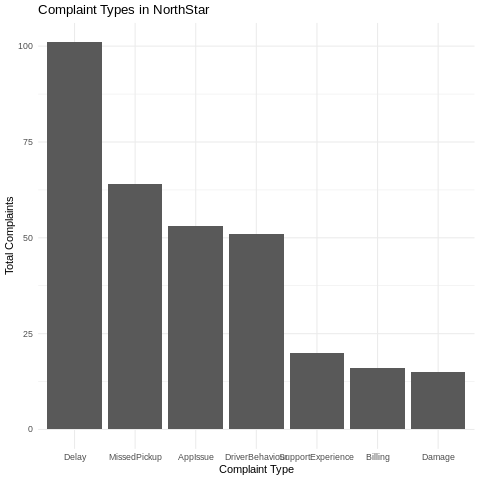

In [9]:
%%R

ggplot(complaint_analysis, aes(x=reorder(complaint_type, -total_complaints), y=total_complaints)) +
  geom_bar(stat="identity") +
  labs(title="Complaint Types in NorthStar", x="Complaint Type", y="Total Complaints") +
  theme_minimal()

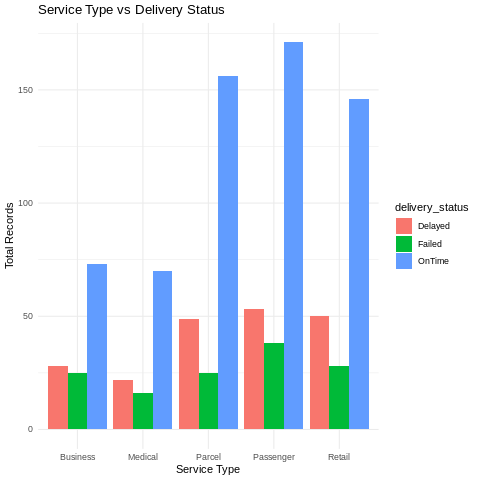

In [10]:
%%R

ggplot(joined_analysis, aes(x=service_type, y=total, fill=delivery_status)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Service Type vs Delivery Status", x="Service Type", y="Total Records") +
  theme_minimal()